# LibPressio

[![Citation]](https://doi.org/10.1109/drbsd754563.2021.00005)
[![Source]](https://github.com/robertu94/libpressio)
[![Documentation]](https://robertu94.github.io/libpressio/)

[Citation]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[Source]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[Documentation]: https://img.shields.io/badge/documentation-grey?style=for-the-badge&logo=readthedocs&logoColor=white

LibPressio [^libpressio] is a compression framework that simplifies compressor configuration and targets deployment in high-performance computing. LibPressio provides common interfaces for several types of plugins, including data I/O, data domains, compressors, metrics, and parallelisation. LibPressio also provides convenient global configuration options e.g. for bounding the pointwise absolute error, such that users do not need to learn the various compressor-specific configuration formats.

The native installation of LibPressio can be configured to include wrappers for various scientific compressors, including ZFP, SZ3, and SPERR. The version provided in `numcodecs-wasm-pressio` does not yet include these optional compressors. The auto-tuning meta-compressor, OptZConfig [^optzconfig], is also not yet included.

[^libpressio]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. In *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

[^optzconfig]: Underwood, R., Calhoun, J. C., Di, S., Apon, A., & Cappello, F. (2022). OptZConfig: Efficient parallel optimization of lossy compression configuration. *IEEE Transactions on Parallel and Distributed Systems*, 33(12), 3505–3519. Available from: [doi:10.1109/tpds.2022.3154096](https://doi.org/10.1109/tpds.2022.3154096).

In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Importing the `Pressio` meta-compressor

In [4]:
from numcodecs_wasm_pressio import Pressio

In [5]:
?Pressio

Init signature:
Pressio(
    compressor_id,
    _version='1.0.0',
    compressor_config={},
    early_config={},
    metric_results={},
    name=None,
)
Docstring:     
Pressio codec which applies the identity function, i.e. passes through the
input unchanged during encoding and decoding.

Parameters
----------
compressor_id : ...
    The id of the compressor
_version : ..., optional, default = "1.0.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
compressor_config : ..., optional, default = {}
    Configuration for the compressor
early_config : ..., optional, default = {}
    Configuration for the structure of the compressor
metric_results : ..., optional, default = {}
    Results of the compressor metrics (output-only)
name : ..., optional, default = None
    Optional name for the compressor when used in hierarchical mode
File:           ~/egu26-compression-sc2.5/.venv/lib/python3.13/site-packages/numcodecs_wasm_pressio/__init__.py
Type:          

### Supported Compressors

The complete list of supported compressors can be inspected by providing an invalid compressor id:

In [6]:
try:
    Pressio(compressor_id="???")
except Exception as err:
    print(err)


 1 | {"compressor_id":"???"}
   |                        ^ invalid compressor id ???, choose one of: `binning`, `bzip2`, `cast`, `chunking`, `delta_encoding`, `lambda_fn`, `linear_quantizer`, `log_transform`, `mask_binning`, `mask_interpolation`, `noop`, `pipeline`, `pressio`, `pw_rel`, `remove_background`, `repeat`, `resize`, `roibin`, `sample`, `switch`, `threshold_small`, `transpose` at line 1 column 23



## Bounding the pointwise absolute error

Pressio can bound the absolute error for a supporting compressor, e.g. linear quantisation, using:

In [7]:
eb_abs = 1.0

Pressio(
    compressor_id="linear_quantizer",
    early_config={"linear_quantizer:compressor": "bzip2"},
    compressor_config={"pressio:abs": eb_abs},
)

Pressio(compressor_id='linear_quantizer', early_config={'linear_quantizer:compressor': 'bzip2'}, compressor_config={'bzip2:block_size_100k': 9, 'bzip2:metric': 'noop', 'bzip2:small': 0, 'bzip2:verbosity': 0, 'bzip2:work_factor': 30, 'linear_quantizer:auto_step': 0, 'linear_quantizer:compressor': 'bzip2', 'linear_quantizer:metric': 'noop', 'linear_quantizer:step': 1.0, 'metrics:copy_compressor_results': 1, 'metrics:errors_fatal': 1, 'pressio:abs': 1.0, 'pressio:lossless': 9, 'pressio:metric': 'noop'}, _version='1.0.0')

## Bounding the range-relative error

Pressio can bound the range-relative error for a supporting compressor using:

```python
eb_range_rel = 0.01

Pressio(compressor_id="...", compressor_config={"pressio:rel": eb_range_rel})
```

## Bounding the pointwise relative error

Pressio can bound the relative error for a supporting compressor using:

```python
eb_rel = 0.01

Pressio(compressor_id="...", compressor_config={"pressio:pw_rel": eb_rel})
```

Alternatively, the `pw_rel` meta-compressor plugin can be used to transform the relative error bound into an absolute error bound for a compressor that only supports absolute error bounds using:

In [8]:
eb_rel = 0.01

Pressio(
    compressor_id="pw_rel",
    early_config={
        "pw_rel:abs_comp": "linear_quantizer",
        "linear_quantizer:compressor": "bzip2",
        "pw_rel:sign_comp": "bzip2",
    },
    compressor_config={"pressio:pw_rel": eb_rel},
)

Pressio(compressor_id='pw_rel', early_config={'linear_quantizer:compressor': 'bzip2', 'pw_rel:abs_comp': 'linear_quantizer', 'pw_rel:sign_comp': 'bzip2'}, compressor_config={'bzip2:block_size_100k': 9, 'bzip2:metric': 'noop', 'bzip2:small': 0, 'bzip2:verbosity': 0, 'bzip2:work_factor': 30, 'linear_quantizer:auto_step': 0, 'linear_quantizer:compressor': 'bzip2', 'linear_quantizer:metric': 'noop', 'linear_quantizer:step': 0.0, 'metrics:copy_compressor_results': 1, 'metrics:errors_fatal': 1, 'pressio:abs': 0.0, 'pressio:lossless': 9, 'pressio:metric': 'noop', 'pressio:pw_rel': 0.009999999776482582, 'pw_rel:abs_comp': 'linear_quantizer', 'pw_rel:metric': 'noop', 'pw_rel:sign_comp': 'bzip2'}, _version='1.0.0')

## Preserving Missing Values

LibPressio preserves NaN values if the underlying compressor preserves NaN values. If the underlying compressor raises an exception when the data includes NaN values, the `mask_interpolation` meta-compressor can be used to replace the NaN values with a fill value using:

In [9]:
da = xr.DataArray(data=np.array([1.0, np.nan, 2.0]))  # for example

Pressio(
    compressor_id="mask_interpolation",
    early_config={
        "mask_interpolation:compressor": "...",
    },
    compressor_config={
        "mask_interpolation:mask": np.isnan(da.values).tolist(),
        "mask_interpolation:mask_mode": "fill",
        "mask_interpolation:fill": np.nanmean(da),
    },
)

Pressio(compressor_id='mask_interpolation', early_config={'mask_interpolation:compressor': '...'}, compressor_config={'mask_interpolation:compressor': 'noop', 'mask_interpolation:fill': 1.5, 'mask_interpolation:mask': [False, True, False], 'mask_interpolation:mask_mode': 'fill', 'mask_interpolation:metric': 'noop', 'mask_interpolation:nthreads': 1, 'metrics:copy_compressor_results': 1, 'metrics:errors_fatal': 1, 'noop:metric': 'noop', 'pressio:metric': 'noop', 'pressio:nthreads': 1}, _version='1.0.0')

## Example

In [10]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [11]:
eb_rel = 0.01  # 1%

codec = Pressio(
    compressor_id="pw_rel",
    early_config={
        "pw_rel:abs_comp": "linear_quantizer",
        "linear_quantizer:compressor": "bzip2",
        "pw_rel:sign_comp": "bzip2",
        "pressio:metric": "composite",
    },
    compressor_config={
        "pressio:pw_rel": eb_rel,
        # record some metrics about compression
        "composite:plugins": ["input_stats", "size", "max_error"],
    },
)

In [12]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc, out=np.empty(da.shape, dtype=da.dtype)))

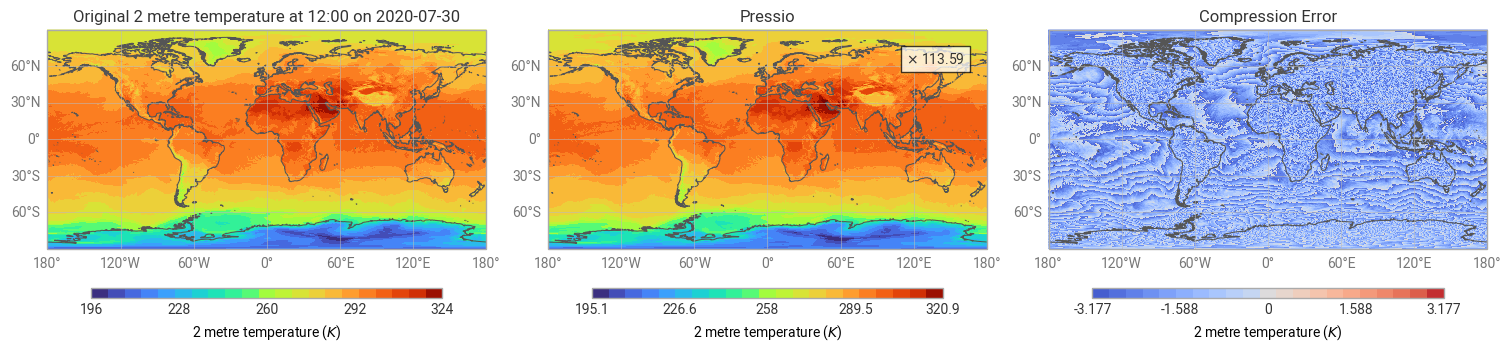

In [13]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec, fig.add_map(0, 1), title="Pressio", cr=da.nbytes / np.array(da_enc).nbytes
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()

In [14]:
codec.get_config().get("metric_results", {})

{'input_stat:compress_input_dims': [[2], [721], [1440]],
 'input_stat:compress_input_types': [0],
 'input_stat:compress_output_dims': [[146242]],
 'input_stat:compress_output_types': [10],
 'input_stat:decompress_input_dims': [[146242]],
 'input_stat:decompress_input_types': [2],
 'input_stat:decompress_output_dims': [[2], [721], [1440]],
 'input_stat:decompress_output_types': [0],
 'max_error:max_error': 3.1765521635285268,
 'max_error:max_error_index': 390462,
 'size:bit_rate': 0.563422715364463,
 'size:compressed_size': 146242,
 'size:compression_ratio': 113.59144431832168,
 'size:decompressed_size': 16611840,
 'size:uncompressed_size': 16611840}